In [2]:
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment Ready")

print(pd.__version__)

Environment Ready
3.0.1


In [13]:
df = pd.read_csv("data/AB_Test.csv")

df.head(5)


,USER_ID,VARIANT_NAME,REVENUE
0,737,variant,0.0
1,2423,control,0.0
2,9411,control,0.0
3,7311,control,0.0
4,6174,variant,0.0


In [11]:
print (df.shape)
df.info()

(10000, 3)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   USER_ID       10000 non-null  int64  
 1   VARIANT_NAME  10000 non-null  str    
 2   REVENUE       10000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 234.5 KB


In [12]:
df.describe()

,USER_ID,REVENUE
count,10000.000000,10000.000000
mean,4981.080200,0.099447
std,2890.590115,2.318529
min,2.000000,0.000000
25%,2468.750000,0.000000
50%,4962.000000,0.000000
75%,7511.500000,0.000000
max,10000.000000,196.010000


In [15]:
df["VARIANT_NAME"].value_counts()

VARIANT_NAME
variant    5016
control    4984
Name: count, dtype: int64

In [17]:
df["USER_ID"].nunique(), len(df)

(6324, 10000)

We have 10k entries and 3 columns. There is equal split between variant (5016)and control (4984). 
We have 6324 unique user out of 10k entries which mean we have 3,676 duplicate user entries.
Looking at Revenue 75% users have 0 and Max revenue is 196 and mean is 0.099447, IT means data is higly Skewed. We should exclude duplicate user entries. 

In [18]:
df.groupby("USER_ID")["VARIANT_NAME"].nunique().value_counts()

VARIANT_NAME
1    4783
2    1541
Name: count, dtype: int64

Independence is broken since 1541 appears in both group(variants)

In [19]:
# to check if experiment/testing is randomised at user level
df.groupby("USER_ID").size().describe()

count    6324.000000
mean        1.581278
std         0.811629
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         6.000000
dtype: float64

We have 6324 unique users in 10,000 rows.
Most users appear once. Some appear multiple times, Up to 6 times.
This strongly suggests that it's event-level or transaction-level data.

1,541 users appear in BOTH control and variant, we will remove them to have independence between the groups and have proper experimental unit. 

In [24]:
# Counting how many unique variants each user has
user_variant_counts = df.groupby("USER_ID")["VARIANT_NAME"].nunique()

# Keeping only users with exactly 1 variant
valid_users = user_variant_counts[user_variant_counts == 1].index

# Filtering dataset
clean_df = df[df["USER_ID"].isin(valid_users)]

clean_df.shape

(6070, 3)

In [25]:
clean_df["USER_ID"].nunique()

4783

In [26]:
#Revenue per user

user_level_df = (
    clean_df
    .groupby(["USER_ID", "VARIANT_NAME"], as_index=False)["REVENUE"]
    .sum()
)

user_level_df.head()

,USER_ID,VARIANT_NAME,REVENUE
0,2,control,0.0
1,4,variant,0.0
2,5,variant,0.0
3,6,variant,0.0
4,9,variant,0.0


In [29]:
user_level_df.nunique()

USER_ID         4783
VARIANT_NAME       2
REVENUE           71
dtype: int64

Seems like data is ready now, we have 4783 unique users, 2 variants, and 71 Entry in revenue column. 
Now lets check if Revenue is skewed or are their any outliers

In [30]:
#Seperating two groups variant and control
control = user_level_df[user_level_df["VARIANT_NAME"] == "control"]["REVENUE"]
variant = user_level_df[user_level_df["VARIANT_NAME"] == "variant"]["REVENUE"]

control.describe(), variant.describe()

(count    2390.000000
 mean        0.196887
 std         4.172201
 min         0.000000
 25%         0.000000
 50%         0.000000
 75%         0.000000
 max       196.010000
 Name: REVENUE, dtype: float64,
 count    2393.000000
 mean        0.074935
 std         0.858207
 min         0.000000
 25%         0.000000
 50%         0.000000
 75%         0.000000
 max        23.040000
 Name: REVENUE, dtype: float64)

Most users in both groupd generate No revenue, 75% in both have 0 revenue and their median are 0. 
Control has extreme outlier of 196 and it distorts are mean comparison.
No Normal Distribution.

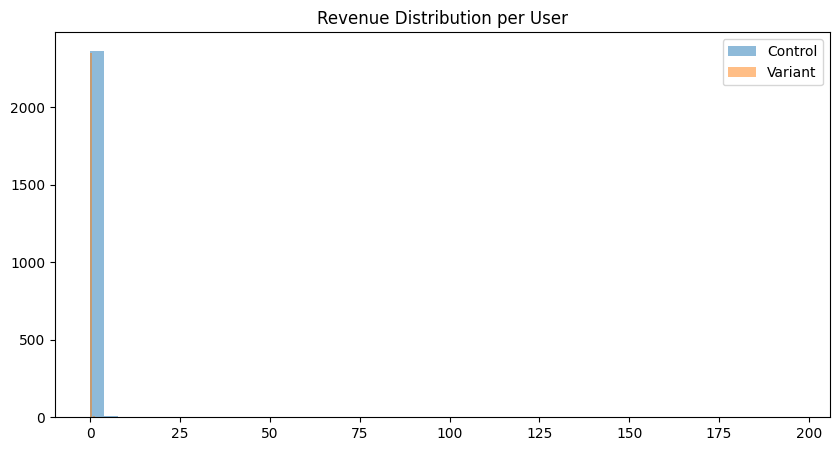

In [31]:
plt.figure(figsize=(10,5))
plt.hist(control, bins=50, alpha=0.5, label="Control")
plt.hist(variant, bins=50, alpha=0.5, label="Variant")
plt.legend()
plt.title("Revenue Distribution per User")
plt.show()

/var/folders/sy/ywmjfg9n2n78tqdr4z3f03hh0000gn/T/ipykernel_69779/1164282980.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([control, variant], labels=["Control", "Variant"])


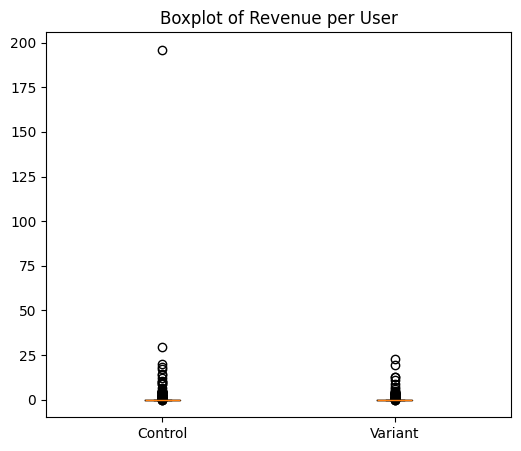

In [32]:
plt.figure(figsize=(6,5))
plt.boxplot([control, variant], labels=["Control", "Variant"])
plt.title("Boxplot of Revenue per User")
plt.show()

Question still remains which variant increase probability of purchase?
Sinces data is highly skewed and outliers are extreme, we will shift our approach instead of Which variants brings more revenue to which variants pushes to purchase. 
if the user has Purchased or Not Purchased.

Converted = 1 if revenue > 0
Converted = 0 if revenue == 0

In [33]:
user_level_df["CONVERTED"] = (user_level_df["REVENUE"] > 0).astype(int)

user_level_df.head()

,USER_ID,VARIANT_NAME,REVENUE,CONVERTED
0,2,control,0.0,0
1,4,variant,0.0,0
2,5,variant,0.0,0
3,6,variant,0.0,0
4,9,variant,0.0,0


In [34]:
conversion_summary = (
    user_level_df
    .groupby("VARIANT_NAME")["CONVERTED"]
    .agg(["count", "sum", "mean"])
)

conversion_summary

,count,sum,mean
VARIANT_NAME,,,
control,2390,54,0.022594
variant,2393,42,0.017551


CONTROL Conversion rate = 2.26%
VARIANT Conversion rate = 1.76%

Statistically:
Null Hypothesis (H₀):
Conversion_control = Conversion_variant

Alternative Hypothesis (H₁):
Conversion_variant > Conversion_control

Since our question is directional (increase), we will use a one-tailed test.

In [ ]:
#Two proportion Z-Test
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

conversions = np.array([54, 42])
samples = np.array([2390, 2393])

z_stat, p_value = proportions_ztest(
    conversions,
    samples,
    alternative='larger'   # testing if control > variant
)

print ('Z-Test:', z_stat, 'P-Value:', p_value)

Z-Test: 1.2434323723364615 P-Value: 0.10685427363863725


Since: 0.1069 > 0.05
We fail to reject the null hypothesis.
There is not enough statistical evidence that control is better than variant.
conversion rate is 54 and 42 out of 2400 user per group - The signal is quite small

# Conclusion
Based on this dataset:

There is no statistically significant evidence that variant improves conversion.
In fact, raw data suggests variant might be worse.
But evidence is weak.

Important:
Failing to reject H₀ does NOT mean both are equal.
It means we don’t have enough evidence to claim difference.